# Introduction to Neural Networks

This notebook introduces the fundamental concepts of neural networks, including their architecture, components, and implementation. We'll build a neural network from scratch using NumPy and then implement the same network using higher-level frameworks like TensorFlow/Keras.

## 1. Import Required Libraries

In [1]:
# !pip install tensorflow

# If you have an NVIDIA GPU and want GPU support
# !pip install tensorflow-gpu

In [2]:
# import tensorflow as tf
# print(f"TensorFlow version: {tf.__version__}")

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.style.use('fivethirtyeight')
sns.set(font_scale=1.2)

# Check if TensorFlow/Keras is available, otherwise show message
try:
    import tensorflow as tf
    from tensorflow import keras
    print(f"TensorFlow version: {tf.__version__}")
    print(f"Keras version: {tf.keras.__version__}")
    tf.random.set_seed(42)
    TF_AVAILABLE = True
except ImportError:
    print("TensorFlow not available. Some parts of this notebook will be skipped.")
    TF_AVAILABLE = False

TensorFlow not available. Some parts of this notebook will be skipped.


## 2. Understanding Neural Network Components

Neural networks are computational models inspired by the human brain. They consist of the following key components:

### Basic Building Blocks

1. **Neurons**: The fundamental units that receive inputs, process them, and generate an output.
2. **Weights**: Parameters that determine the strength of connections between neurons.
3. **Biases**: Additional parameters that allow the model to fit better to the data.
4. **Activation Functions**: Non-linear functions that introduce non-linearity into the network.
5. **Layers**: Groups of neurons that process information in a similar way.

Let's visualize a single neuron and a multi-layer neural network architecture.

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Sans'

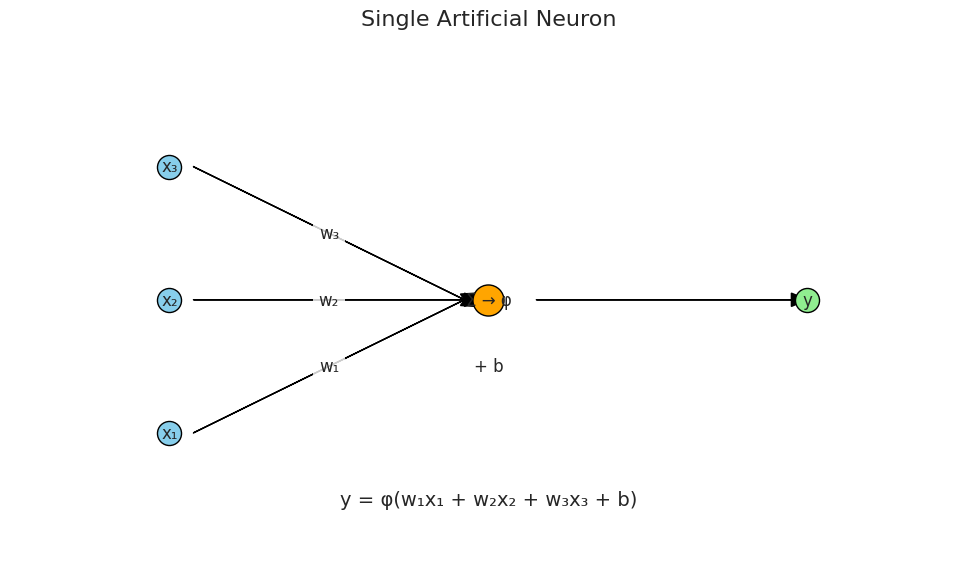

In [5]:
# Visualize a single neuron
def draw_neuron():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Inputs
    inputs = ['x₁', 'x₂', 'x₃']
    input_coords = [(0, i) for i in range(len(inputs))]
    
    # Neuron
    neuron_coord = (2, 1)
    
    # Draw inputs
    for i, (x, y) in enumerate(input_coords):
        ax.scatter(x, y, s=300, c='skyblue', edgecolor='black', zorder=2)
        ax.text(x, y, inputs[i], ha='center', va='center', fontsize=12)
    
    # Draw neuron
    ax.scatter(neuron_coord[0], neuron_coord[1], s=500, c='orange', edgecolor='black', zorder=2)
    ax.text(neuron_coord[0], neuron_coord[1], "Σ → φ", ha='center', va='center', fontsize=12)
    
    # Draw output
    ax.scatter(4, 1, s=300, c='lightgreen', edgecolor='black', zorder=2)
    ax.text(4, 1, 'y', ha='center', va='center', fontsize=12)
    
    # Draw connections with weights
    weights = ['w₁', 'w₂', 'w₃']
    
    for i, (x, y) in enumerate(input_coords):
        ax.arrow(x + 0.15, y, neuron_coord[0] - x - 0.3, neuron_coord[1] - y, 
                head_width=0.1, head_length=0.1, fc='black', ec='black', zorder=1)
        
        # Add weight labels
        mid_x = (x + neuron_coord[0]) / 2
        mid_y = (y + neuron_coord[1]) / 2
        ax.text(mid_x, mid_y, weights[i], ha='center', va='center', fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Draw output connection
    ax.arrow(neuron_coord[0] + 0.3, neuron_coord[1], 4 - neuron_coord[0] - 0.4, 0,
            head_width=0.1, head_length=0.1, fc='black', ec='black', zorder=1)
    
    # Add bias
    ax.text(neuron_coord[0], neuron_coord[1] - 0.5, '+ b', ha='center', va='center', fontsize=12,
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax.set_xlim(-1, 5)
    ax.set_ylim(-1, 3)
    ax.set_title('Single Artificial Neuron', fontsize=16)
    ax.text(2, -0.5, 'y = φ(w₁x₁ + w₂x₂ + w₃x₃ + b)', ha='center', va='center', fontsize=14,
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_neuron()

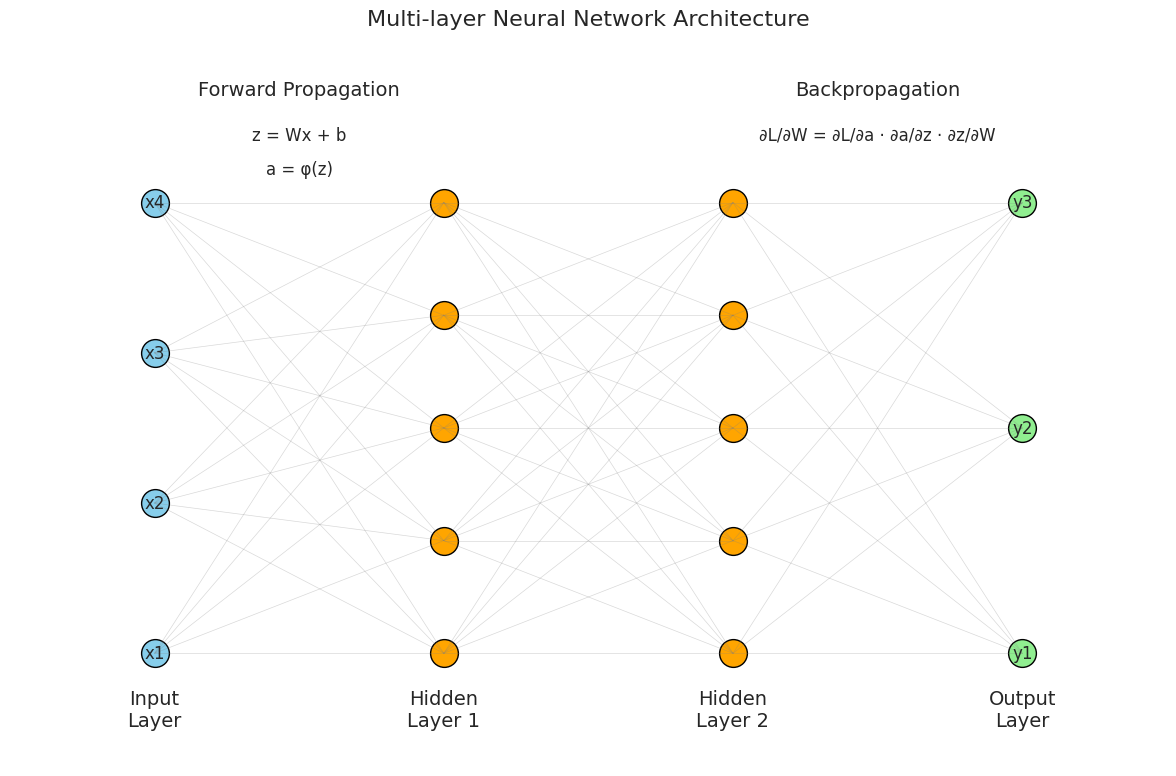

In [6]:
# Visualize a multi-layer neural network
def draw_neural_network():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Define layer sizes and positions
    layers = [4, 5, 5, 3]  # Input, Hidden1, Hidden2, Output
    layer_positions = [1, 3, 5, 7]
    
    # Colors for each layer
    colors = ['skyblue', 'orange', 'orange', 'lightgreen']
    layer_names = ['Input\nLayer', 'Hidden\nLayer 1', 'Hidden\nLayer 2', 'Output\nLayer']
    
    # Draw nodes
    node_positions = []
    
    for l, (layer_size, x_pos, color) in enumerate(zip(layers, layer_positions, colors)):
        layer_nodes = []
        y_positions = np.linspace(0, 4, layer_size)
        
        for i, y_pos in enumerate(y_positions):
            # Draw node
            ax.scatter(x_pos, y_pos, s=400, c=color, edgecolor='black', zorder=2)
            
            # Label the node only for input and output layers
            if l == 0:
                ax.text(x_pos, y_pos, f'x{i+1}', ha='center', va='center', fontsize=12)
            elif l == len(layers) - 1:
                ax.text(x_pos, y_pos, f'y{i+1}', ha='center', va='center', fontsize=12)
            
            layer_nodes.append((x_pos, y_pos))
        
        # Add layer label
        ax.text(x_pos, -0.5, layer_names[l], ha='center', va='center', fontsize=14)
        
        node_positions.append(layer_nodes)
    
    # Draw connections between layers
    for l in range(len(layers) - 1):
        for start_node in node_positions[l]:
            for end_node in node_positions[l + 1]:
                ax.plot([start_node[0], end_node[0]], [start_node[1], end_node[1]], 'gray', alpha=0.3, linewidth=0.5)
    
    # Add mathematical expressions
    ax.text(2, 5, 'Forward Propagation', ha='center', va='center', fontsize=14,
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.text(2, 4.6, 'z = Wx + b', ha='center', va='center', fontsize=12)
    ax.text(2, 4.3, 'a = φ(z)', ha='center', va='center', fontsize=12)
    
    ax.text(6, 5, 'Backpropagation', ha='center', va='center', fontsize=14,
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.text(6, 4.6, '∂L/∂W = ∂L/∂a · ∂a/∂z · ∂z/∂W', ha='center', va='center', fontsize=12)
    
    ax.set_title('Multi-layer Neural Network Architecture', fontsize=16)
    ax.set_xlim(0, 8)
    ax.set_ylim(-1, 5.5)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_neural_network()

## 3. Common Activation Functions

Activation functions introduce non-linearity into neural networks, enabling them to learn complex patterns. Here are the most common activation functions:

1. **Sigmoid**: Maps values to a range between 0 and 1
2. **Tanh**: Maps values to a range between -1 and 1
3. **ReLU (Rectified Linear Unit)**: Returns x if x > 0, otherwise 0
4. **Leaky ReLU**: Returns x if x > 0, otherwise αx (where α is a small constant)

Let's implement and visualize these activation functions:

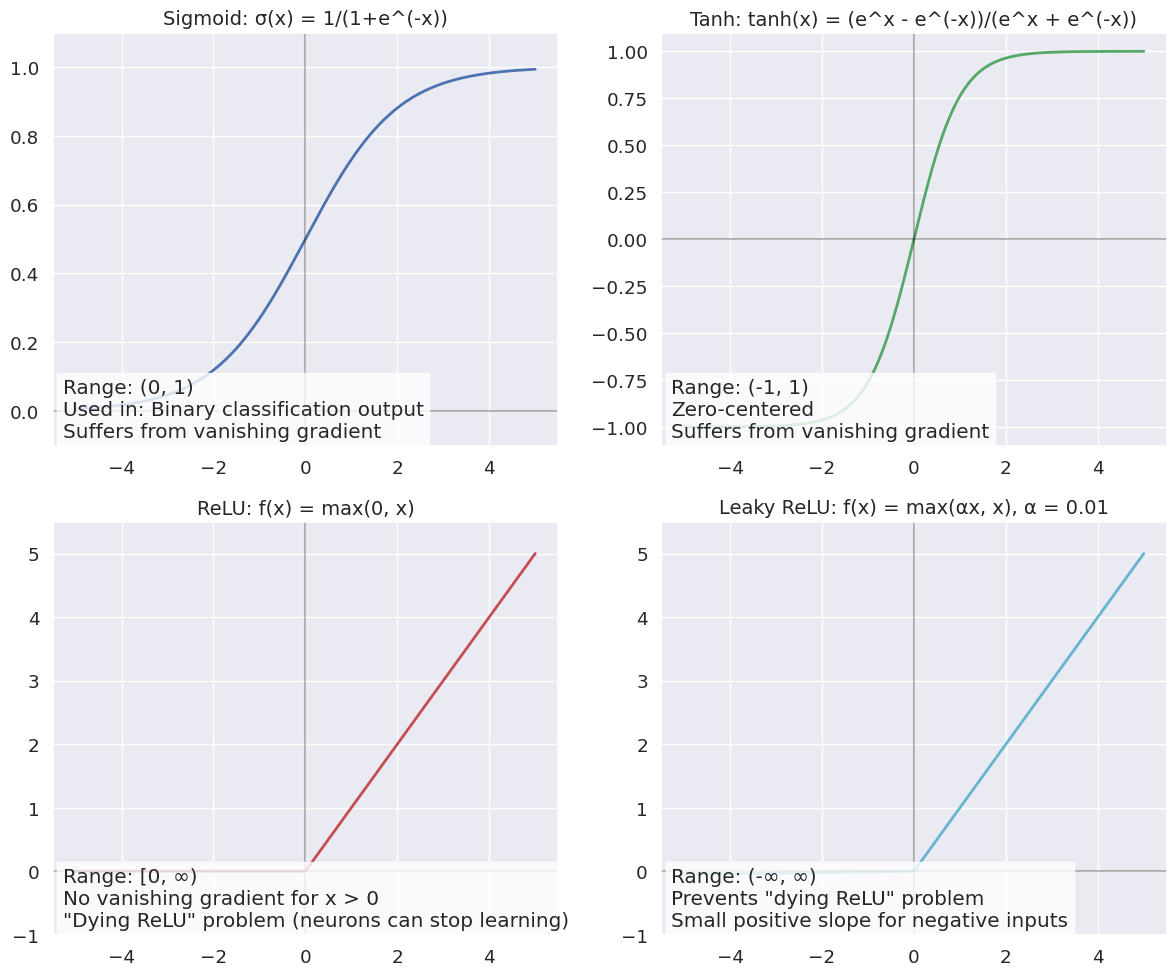

In [7]:
# Implement activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

# Visualize activation functions
def plot_activation_functions():
    x = np.linspace(-5, 5, 1000)
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()
    
    # Sigmoid
    axs[0].plot(x, sigmoid(x), 'b-', linewidth=2)
    axs[0].set_title('Sigmoid: σ(x) = 1/(1+e^(-x))', fontsize=14)
    axs[0].grid(True)
    axs[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axs[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    axs[0].set_ylim(-0.1, 1.1)
    
    # Tanh
    axs[1].plot(x, tanh(x), 'g-', linewidth=2)
    axs[1].set_title('Tanh: tanh(x) = (e^x - e^(-x))/(e^x + e^(-x))', fontsize=14)
    axs[1].grid(True)
    axs[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axs[1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    axs[1].set_ylim(-1.1, 1.1)
    
    # ReLU
    axs[2].plot(x, relu(x), 'r-', linewidth=2)
    axs[2].set_title('ReLU: f(x) = max(0, x)', fontsize=14)
    axs[2].grid(True)
    axs[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axs[2].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    axs[2].set_ylim(-1, 5.5)
    
    # Leaky ReLU
    axs[3].plot(x, leaky_relu(x), 'c-', linewidth=2)
    axs[3].set_title('Leaky ReLU: f(x) = max(αx, x), α = 0.01', fontsize=14)
    axs[3].grid(True)
    axs[3].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axs[3].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    axs[3].set_ylim(-1, 5.5)
    
    # Add activation function properties
    properties = {
        'Sigmoid': [
            'Range: (0, 1)',
            'Used in: Binary classification output',
            'Suffers from vanishing gradient',
        ],
        'Tanh': [
            'Range: (-1, 1)',
            'Zero-centered',
            'Suffers from vanishing gradient',
        ],
        'ReLU': [
            'Range: [0, ∞)',
            'No vanishing gradient for x > 0',
            '"Dying ReLU" problem (neurons can stop learning)',
        ],
        'Leaky ReLU': [
            'Range: (-∞, ∞)',
            'Prevents "dying ReLU" problem',
            'Small positive slope for negative inputs',
        ]
    }
    
    for i, (name, props) in enumerate(properties.items()):
        props_text = '\n'.join(props)
        axs[i].text(0.02, 0.02, props_text, transform=axs[i].transAxes,
                   bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_activation_functions()

## 4. Building a Simple Neural Network from Scratch

Now, let's implement a simple neural network from scratch using NumPy. We'll build a 2-layer network for a binary classification problem:

1. Input layer: Features from our dataset
2. Hidden layer: With configurable number of neurons and activation function
3. Output layer: Single neuron with sigmoid activation for binary classification

Our implementation will include:
- Forward propagation
- Loss calculation
- Backpropagation
- Gradient descent optimization

In [8]:
class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size):
        """
        Initialize a simple neural network with one hidden layer.
        
        Parameters:
        - input_size: Number of input features
        - hidden_size: Number of neurons in the hidden layer
        """
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01  # Input -> Hidden
        self.b1 = np.zeros((1, hidden_size))                       # Hidden layer bias
        self.W2 = np.random.randn(hidden_size, 1) * 0.01           # Hidden -> Output
        self.b2 = np.zeros((1, 1))                                 # Output layer bias
        
        # Store parameters in a dictionary for easy access
        self.parameters = {
            'W1': self.W1,
            'b1': self.b1,
            'W2': self.W2,
            'b2': self.b2
        }
        
        # Initialize lists to store loss history and accuracy history
        self.loss_history = []
        self.accuracy_history = []
    
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to avoid overflow
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid function"""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward_propagation(self, X):
        """
        Perform forward propagation through the network.
        
        Parameters:
        - X: Input features (batch_size, input_size)
        
        Returns:
        - A2: Output predictions
        - cache: Cached values for backpropagation
        """
        # Hidden layer
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = np.tanh(Z1)  # Using tanh for hidden layer
        
        # Output layer
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.sigmoid(Z2)  # Using sigmoid for binary classification
        
        # Cache values for backpropagation
        cache = {
            'Z1': Z1,
            'A1': A1,
            'Z2': Z2,
            'A2': A2
        }
        
        return A2, cache
    
    def compute_loss(self, A2, Y):
        """
        Compute binary cross-entropy loss.
        
        Parameters:
        - A2: Predicted values (batch_size, 1)
        - Y: True labels (batch_size, 1)
        
        Returns:
        - loss: Binary cross-entropy loss
        """
        m = Y.shape[0]
        # Binary cross-entropy loss
        loss = -np.mean(Y * np.log(A2 + 1e-8) + (1 - Y) * np.log(1 - A2 + 1e-8))
        return loss
    
    def backward_propagation(self, X, Y, cache):
        """
        Perform backpropagation to compute gradients.
        
        Parameters:
        - X: Input features (batch_size, input_size)
        - Y: True labels (batch_size, 1)
        - cache: Cached values from forward propagation
        
        Returns:
        - gradients: Dictionary containing gradients for each parameter
        """
        m = X.shape[0]
        
        # Get cached values
        A1 = cache['A1']
        A2 = cache['A2']
        
        # Output layer gradients
        dZ2 = A2 - Y  # Derivative of binary cross-entropy with sigmoid
        dW2 = (1/m) * np.dot(A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        dZ1 = np.dot(dZ2, self.W2.T) * (1 - np.power(A1, 2))  # Derivative of tanh
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # Store gradients
        gradients = {
            'dW1': dW1,
            'db1': db1,
            'dW2': dW2,
            'db2': db2
        }
        
        return gradients
    
    def update_parameters(self, gradients, learning_rate):
        """
        Update parameters using gradient descent.
        
        Parameters:
        - gradients: Dictionary containing gradients for each parameter
        - learning_rate: Learning rate for gradient descent
        """
        self.W1 -= learning_rate * gradients['dW1']
        self.b1 -= learning_rate * gradients['db1']
        self.W2 -= learning_rate * gradients['dW2']
        self.b2 -= learning_rate * gradients['db2']
        
        # Update the parameters dictionary
        self.parameters = {
            'W1': self.W1,
            'b1': self.b1,
            'W2': self.W2,
            'b2': self.b2
        }
    
    def train(self, X, Y, learning_rate=0.01, epochs=1000, print_interval=100):
        """
        Train the neural network using gradient descent.
        
        Parameters:
        - X: Input features (batch_size, input_size)
        - Y: True labels (batch_size, 1)
        - learning_rate: Learning rate for gradient descent
        - epochs: Number of training epochs
        - print_interval: How often to print progress
        
        Returns:
        - loss_history: List of losses at each epoch
        """
        for epoch in range(epochs):
            # Forward propagation
            A2, cache = self.forward_propagation(X)
            
            # Compute loss
            loss = self.compute_loss(A2, Y)
            self.loss_history.append(loss)
            
            # Compute accuracy
            predictions = (A2 > 0.5).astype(int)
            accuracy = np.mean(predictions == Y)
            self.accuracy_history.append(accuracy)
            
            # Backward propagation
            gradients = self.backward_propagation(X, Y, cache)
            
            # Update parameters
            self.update_parameters(gradients, learning_rate)
            
            # Print progress
            if epoch % print_interval == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}: Loss = {loss:.4f}, Accuracy = {accuracy:.4f}")
        
        return self.loss_history, self.accuracy_history
    
    def predict(self, X):
        """
        Make predictions using the trained network.
        
        Parameters:
        - X: Input features (batch_size, input_size)
        
        Returns:
        - predictions: Binary predictions (0 or 1)
        """
        A2, _ = self.forward_propagation(X)
        predictions = (A2 > 0.5).astype(int)
        return predictions

## 5. Training a Simple Neural Network on Synthetic Data

Now, let's create a synthetic dataset and train our neural network on it. We'll:
1. Generate a classification dataset
2. Split it into training and testing sets
3. Standardize the features
4. Train our neural network
5. Evaluate its performance

Epoch 0: Loss = 0.6932, Accuracy = 0.2200
Epoch 200: Loss = 0.2769, Accuracy = 0.9100
Epoch 400: Loss = 0.2121, Accuracy = 0.9257
Epoch 600: Loss = 0.1876, Accuracy = 0.9286
Epoch 800: Loss = 0.1700, Accuracy = 0.9357
Epoch 1000: Loss = 0.1614, Accuracy = 0.9371
Epoch 1200: Loss = 0.1563, Accuracy = 0.9386
Epoch 1400: Loss = 0.1529, Accuracy = 0.9400
Epoch 1600: Loss = 0.1505, Accuracy = 0.9386
Epoch 1800: Loss = 0.1486, Accuracy = 0.9371
Epoch 1999: Loss = 0.1472, Accuracy = 0.9371
Test accuracy: 0.9000


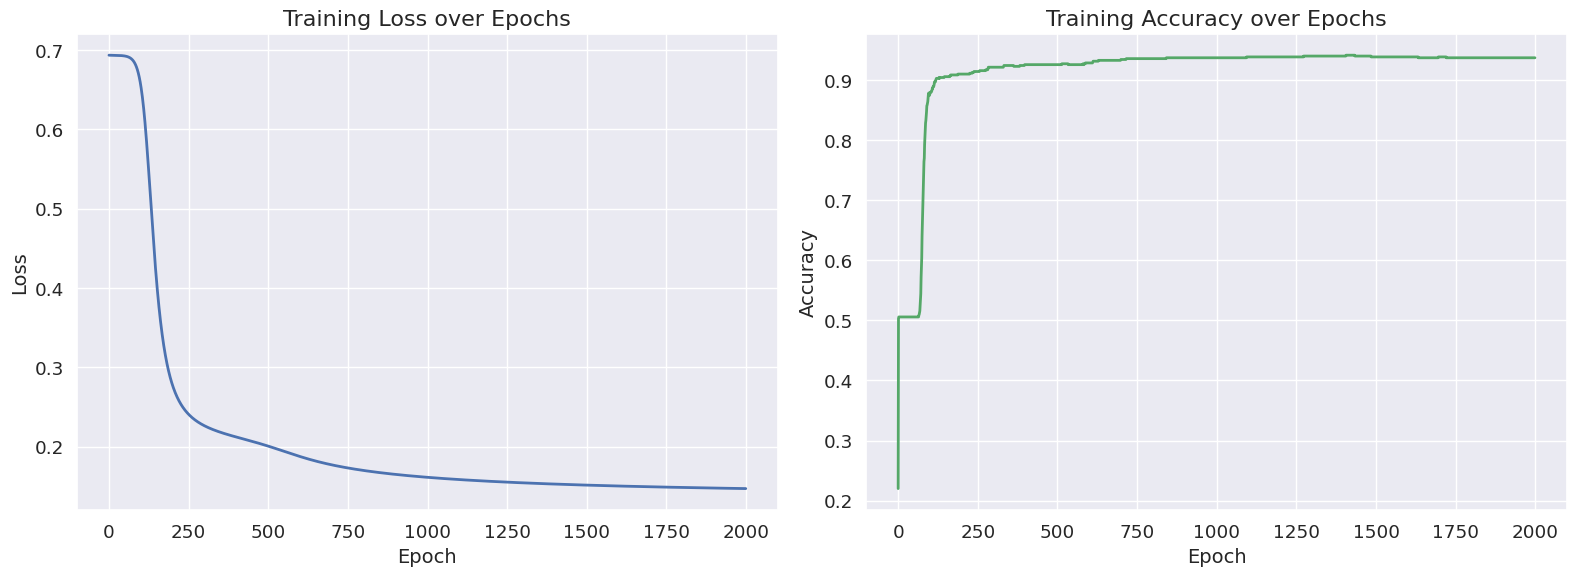

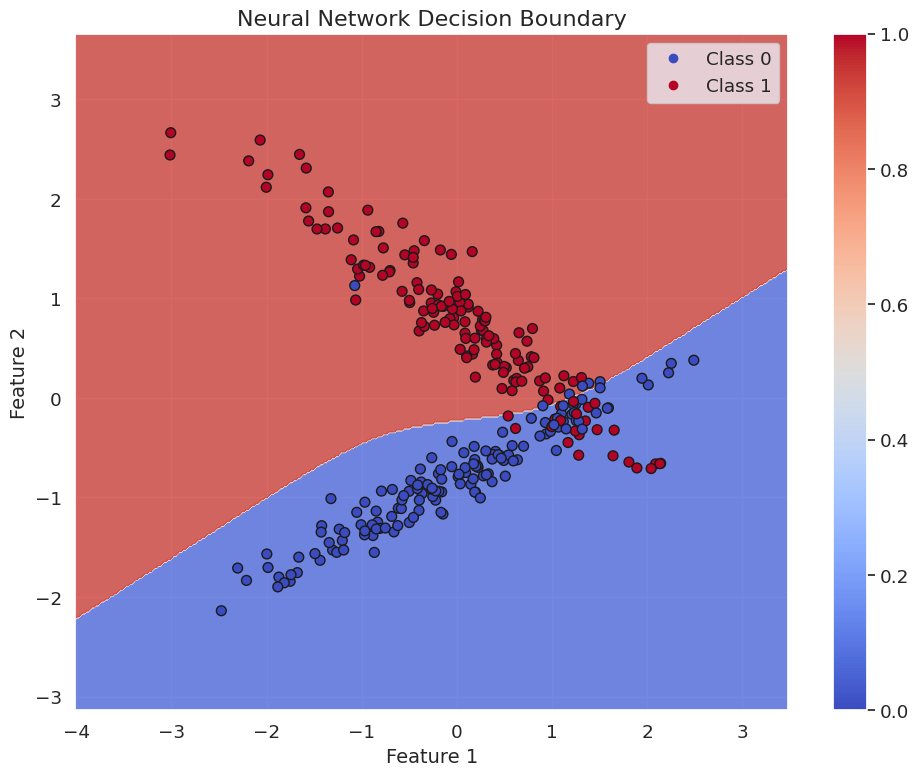

In [9]:
# Generate a synthetic classification dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, 
                          n_clusters_per_class=1, random_state=42)

# Reshape y to be a column vector
y = y.reshape(-1, 1)

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train our neural network
nn = SimpleNeuralNetwork(input_size=2, hidden_size=4)
loss_history, accuracy_history = nn.train(X_train_scaled, y_train, learning_rate=0.1, epochs=2000, print_interval=200)

# Evaluate on test set
y_pred = nn.predict(X_test_scaled)
test_accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot the loss and accuracy history
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot loss history
ax[0].plot(loss_history, 'b-', linewidth=2)
ax[0].set_xlabel('Epoch', fontsize=14)
ax[0].set_ylabel('Loss', fontsize=14)
ax[0].set_title('Training Loss over Epochs', fontsize=16)
ax[0].grid(True)

# Plot accuracy history
ax[1].plot(accuracy_history, 'g-', linewidth=2)
ax[1].set_xlabel('Epoch', fontsize=14)
ax[1].set_ylabel('Accuracy', fontsize=14)
ax[1].set_title('Training Accuracy over Epochs', fontsize=16)
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Visualize the decision boundary
def plot_decision_boundary(model, X, y):
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Make predictions on the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    
    # Plot the original data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.coolwarm, edgecolor='k', s=50)
    plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1'])
    
    plt.xlabel('Feature 1', fontsize=14)
    plt.ylabel('Feature 2', fontsize=14)
    plt.title('Neural Network Decision Boundary', fontsize=16)
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()

# Plot the decision boundary for the test data
plot_decision_boundary(nn, X_test_scaled, y_test)

## 6. Using TensorFlow/Keras for Neural Networks

Now, let's implement the same neural network architecture using TensorFlow/Keras, which provides a higher-level API for building neural networks.

In [10]:
# Check if TensorFlow is available
if TF_AVAILABLE:
    # Create the same neural network architecture using Keras
    model = keras.Sequential([
        keras.layers.Dense(4, activation='tanh', input_shape=(2,)),  # Hidden layer
        keras.layers.Dense(1, activation='sigmoid')                  # Output layer
    ])
    
    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.1),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Train the model
    history = model.fit(
        X_train_scaled, y_train,
        epochs=2000,
        batch_size=32,
        validation_split=0.2,
        verbose=0  # Suppress output for brevity
    )
    
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Test accuracy: {test_accuracy:.4f}")
    
    # Plot training history
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot training & validation loss values
    ax[0].plot(history.history['loss'], 'b-', label='Train', linewidth=2)
    ax[0].plot(history.history['val_loss'], 'r--', label='Validation', linewidth=2)
    ax[0].set_xlabel('Epoch', fontsize=14)
    ax[0].set_ylabel('Loss', fontsize=14)
    ax[0].set_title('Model Loss', fontsize=16)
    ax[0].legend()
    ax[0].grid(True)
    
    # Plot training & validation accuracy values
    ax[1].plot(history.history['accuracy'], 'g-', label='Train', linewidth=2)
    ax[1].plot(history.history['val_accuracy'], 'r--', label='Validation', linewidth=2)
    ax[1].set_xlabel('Epoch', fontsize=14)
    ax[1].set_ylabel('Accuracy', fontsize=14)
    ax[1].set_title('Model Accuracy', fontsize=16)
    ax[1].legend()
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Visualize the TensorFlow model's decision boundary
    def plot_tf_decision_boundary(model, X, y):
        h = 0.02  # Step size in the mesh
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        
        # Make predictions on the meshgrid
        Z = (model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5).astype(int)
        Z = Z.reshape(xx.shape)
        
        # Plot the decision boundary
        plt.figure(figsize=(10, 8))
        plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
        
        # Plot the original data points
        scatter = plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.coolwarm, edgecolor='k', s=50)
        plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1'])
        
        plt.xlabel('Feature 1', fontsize=14)
        plt.ylabel('Feature 2', fontsize=14)
        plt.title('TensorFlow/Keras Neural Network Decision Boundary', fontsize=16)
        plt.colorbar(scatter)
        plt.tight_layout()
        plt.show()
    
    # Plot the decision boundary for the TensorFlow model
    plot_tf_decision_boundary(model, X_test_scaled, y_test)
    
    # Show the model summary
    print("\nTensorFlow/Keras Model Summary:")
    model.summary()
    
    # Visualize the model architecture
    keras.utils.plot_model(model, 'keras_model.png', show_shapes=True, show_dtype=True)
    try:
        display(keras.utils.plot_model(model, 'keras_model.png', show_shapes=True, show_dtype=True, show_layer_names=True))
    except:
        print("Unable to display model visualization. Model summary shown instead.")
else:
    print("TensorFlow is not available. Skipping TensorFlow/Keras implementation.")

TensorFlow is not available. Skipping TensorFlow/Keras implementation.


## 7. Neural Network Architectures

Neural networks can be organized into various architectures, each suited for specific types of problems:

### 1. Feedforward Neural Networks (FNN)
- Simplest architecture, information moves in one direction
- Used for classification, regression, and pattern recognition
- Example applications: Customer classification, price prediction

### 2. Convolutional Neural Networks (CNN)
- Specialized for processing grid-like data (e.g., images)
- Uses convolutional layers to detect spatial patterns
- Example applications: Image classification, facial recognition, object detection

### 3. Recurrent Neural Networks (RNN)
- Designed for sequential data with temporal dependencies
- Contains feedback connections, allowing information to persist
- Example applications: Time series prediction, language modeling, speech recognition

### 4. Long Short-Term Memory (LSTM) Networks
- Special kind of RNN designed to address vanishing gradient problem
- Can remember patterns over long sequences
- Example applications: Machine translation, speech synthesis, text generation

### 5. Transformers
- Uses self-attention mechanisms to process sequences in parallel
- Highly effective for natural language processing tasks
- Example applications: Language translation, text summarization, sentiment analysis

Let's visualize some of these architectures:

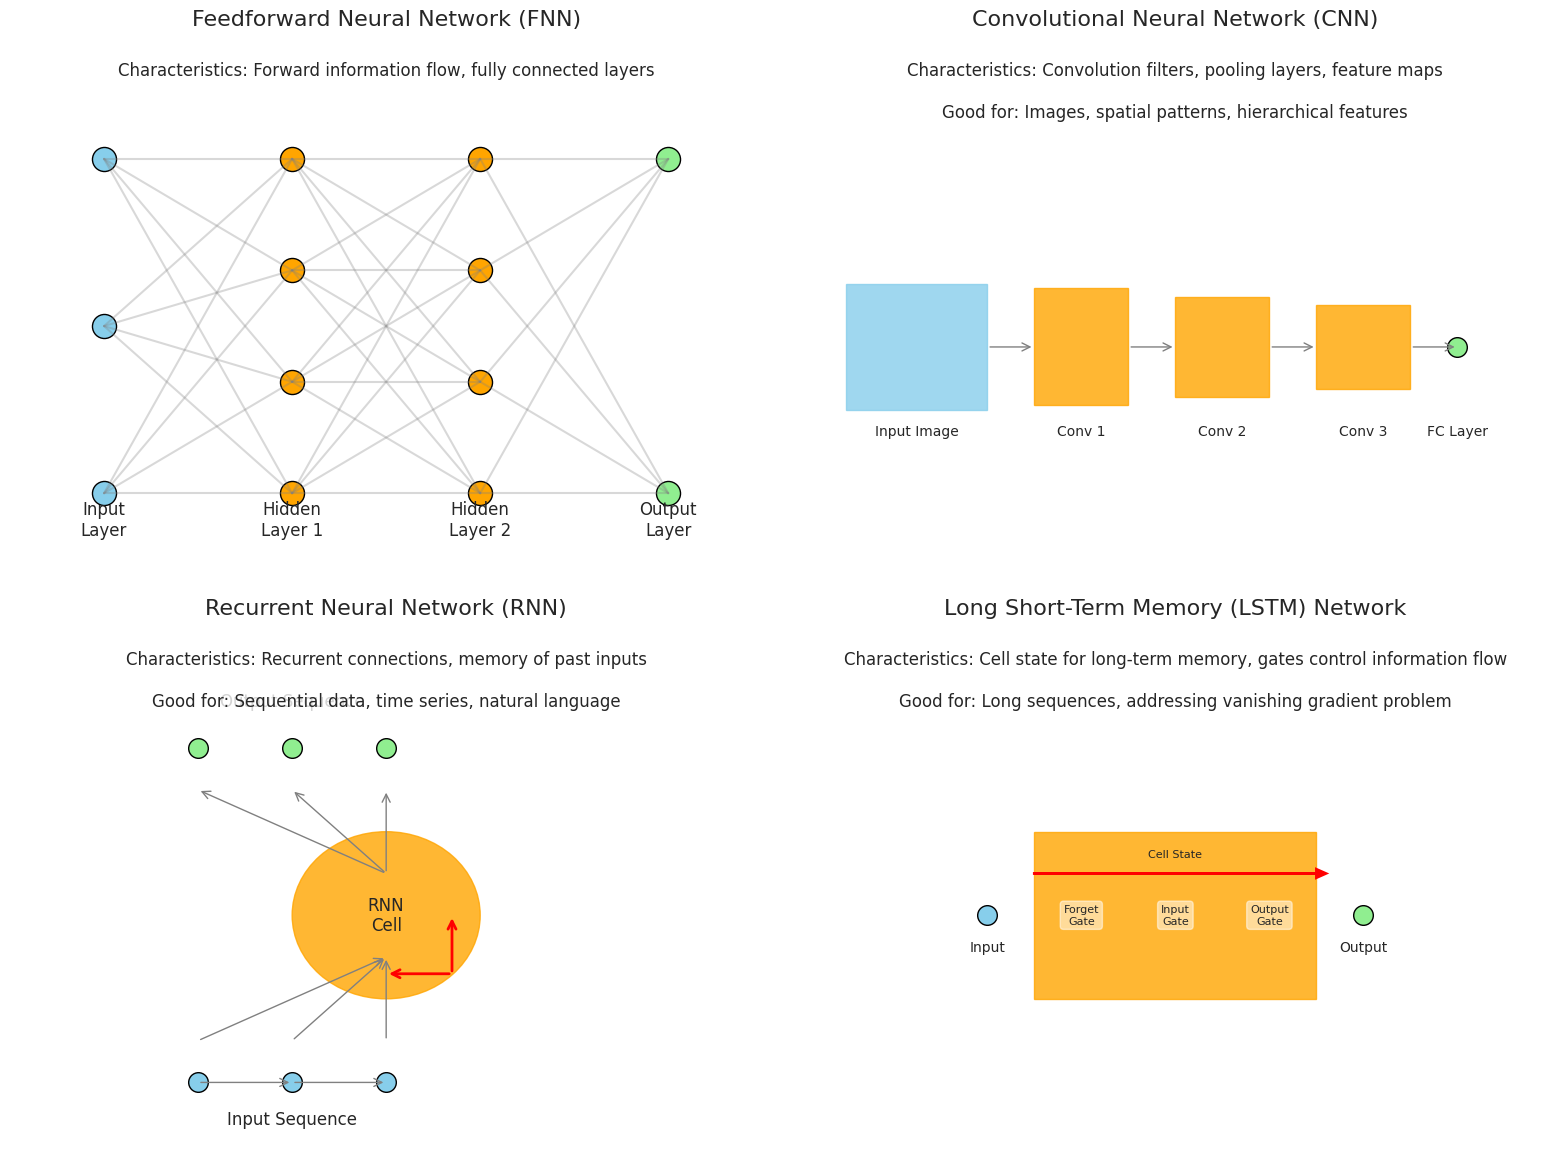

In [11]:
# Visualizing different neural network architectures
def plot_nn_architectures():
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Feedforward Neural Network
    ax = axs[0, 0]
    ax.set_title('Feedforward Neural Network (FNN)', fontsize=16)
    
    layers = [3, 4, 4, 2]
    layer_positions = [1, 3, 5, 7]
    colors = ['skyblue', 'orange', 'orange', 'lightgreen']
    
    # Draw nodes
    for l, (layer_size, x_pos, color) in enumerate(zip(layers, layer_positions, colors)):
        y_positions = np.linspace(1, 5, layer_size)
        
        for y_pos in y_positions:
            ax.scatter(x_pos, y_pos, s=300, c=color, edgecolor='black', zorder=2)
    
        # Add layer labels
        if l == 0:
            ax.text(x_pos, 0.5, "Input\nLayer", ha='center', fontsize=12)
        elif l == len(layers) - 1:
            ax.text(x_pos, 0.5, "Output\nLayer", ha='center', fontsize=12)
        else:
            ax.text(x_pos, 0.5, f"Hidden\nLayer {l}", ha='center', fontsize=12)
    
    # Draw connections
    for l in range(len(layers) - 1):
        for i in range(layers[l]):
            for j in range(layers[l + 1]):
                y1 = np.linspace(1, 5, layers[l])[i]
                y2 = np.linspace(1, 5, layers[l + 1])[j]
                ax.plot([layer_positions[l], layer_positions[l + 1]], 
                       [y1, y2], 'gray', alpha=0.3)
    
    ax.text(4, 6, "Characteristics: Forward information flow, fully connected layers", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 6.5)
    ax.axis('off')
    
    # 2. Convolutional Neural Network
    ax = axs[0, 1]
    ax.set_title('Convolutional Neural Network (CNN)', fontsize=16)
    
    # Draw input image
    ax.add_patch(plt.Rectangle((0.5, 2), 1.5, 1.5, color='skyblue', alpha=0.8))
    ax.text(1.25, 1.7, "Input Image", ha='center', fontsize=10)
    
    # Draw convolutional layers
    x_positions = [2.5, 4, 5.5]
    heights = [1.4, 1.2, 1.0]
    for i, (x, h) in enumerate(zip(x_positions, heights)):
        ax.add_patch(plt.Rectangle((x, 2 + (1.5-h)/2), 1, h, color='orange', alpha=0.8))
        ax.text(x + 0.5, 1.7, f"Conv {i+1}", ha='center', fontsize=10)
    
    # Draw fully connected layers
    ax.scatter([7], [2.75], s=200, c='lightgreen', edgecolor='black')
    ax.text(7, 1.7, "FC Layer", ha='center', fontsize=10)
    
    # Draw connections
    ax.annotate("", xy=(2.5, 2.75), xytext=(2, 2.75), arrowprops=dict(arrowstyle="->", color='gray'))
    ax.annotate("", xy=(4, 2.75), xytext=(3.5, 2.75), arrowprops=dict(arrowstyle="->", color='gray'))
    ax.annotate("", xy=(5.5, 2.75), xytext=(5, 2.75), arrowprops=dict(arrowstyle="->", color='gray'))
    ax.annotate("", xy=(7, 2.75), xytext=(6.5, 2.75), arrowprops=dict(arrowstyle="->", color='gray'))
    
    ax.text(4, 6, "Characteristics: Convolution filters, pooling layers, feature maps", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.text(4, 5.5, "Good for: Images, spatial patterns, hierarchical features", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 6.5)
    ax.axis('off')
    
    # 3. Recurrent Neural Network
    ax = axs[1, 0]
    ax.set_title('Recurrent Neural Network (RNN)', fontsize=16)
    
    # Draw RNN cell
    cell_center = (4, 3)
    cell_radius = 1
    cell = plt.Circle(cell_center, cell_radius, color='orange', alpha=0.8)
    ax.add_patch(cell)
    ax.text(cell_center[0], cell_center[1], "RNN\nCell", ha='center', va='center', fontsize=12)
    
    # Draw input sequence
    for i in range(3):
        ax.scatter(2 + i * 1, 1, s=200, c='skyblue', edgecolor='black')
        if i < 2:
            ax.annotate("", xy=(3 + i * 1, 1), xytext=(2 + i * 1, 1), 
                       arrowprops=dict(arrowstyle="->", color='gray'))
    ax.text(3, 0.5, "Input Sequence", ha='center', fontsize=12)
    
    # Draw output sequence
    for i in range(3):
        ax.scatter(2 + i * 1, 5, s=200, c='lightgreen', edgecolor='black')
    ax.text(3, 5.5, "Output Sequence", ha='center', fontsize=12)
    
    # Draw connections
    for i in range(3):
        # Input to cell
        ax.annotate("", xy=(cell_center[0], cell_center[1] - 0.5), 
                   xytext=(2 + i * 1, 1.5),
                   arrowprops=dict(arrowstyle="->", color='gray'))
        # Cell to output
        ax.annotate("", xy=(2 + i * 1, 4.5), 
                   xytext=(cell_center[0], cell_center[1] + 0.5),
                   arrowprops=dict(arrowstyle="->", color='gray'))
    
    # Draw recurrent connection
    ax.annotate("", xy=(cell_center[0] + 0.7, cell_center[1]), 
               xytext=(cell_center[0] + 0.7, cell_center[1] - 0.7),
               arrowprops=dict(arrowstyle="->", color='red', lw=2))
    ax.annotate("", xy=(cell_center[0], cell_center[1] - 0.7), 
               xytext=(cell_center[0] + 0.7, cell_center[1] - 0.7),
               arrowprops=dict(arrowstyle="->", color='red', lw=2))
    
    ax.text(4, 6, "Characteristics: Recurrent connections, memory of past inputs", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.text(4, 5.5, "Good for: Sequential data, time series, natural language", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 6.5)
    ax.axis('off')
    
    # 4. LSTM Network
    ax = axs[1, 1]
    ax.set_title('Long Short-Term Memory (LSTM) Network', fontsize=16)
    
    # Draw LSTM cell
    cell_center = (4, 3)
    rect = plt.Rectangle((cell_center[0] - 1.5, cell_center[1] - 1), 3, 2, 
                        color='orange', alpha=0.8)
    ax.add_patch(rect)
    
    # Draw internal components
    components = ['Forget\nGate', 'Input\nGate', 'Output\nGate']
    for i, comp in enumerate(components):
        ax.text(cell_center[0] - 1 + i * 1, cell_center[1], comp, 
               ha='center', va='center', fontsize=8,
               bbox=dict(facecolor='white', alpha=0.5, boxstyle='round'))
    
    # Draw cell state line
    ax.arrow(cell_center[0] - 1.5, cell_center[1] + 0.5, 3, 0, 
            head_width=0.1, head_length=0.1, fc='red', ec='red', lw=2)
    ax.text(cell_center[0], cell_center[1] + 0.7, "Cell State", ha='center', fontsize=8)
    
    # Draw input
    ax.scatter(2, 3, s=200, c='skyblue', edgecolor='black')
    ax.text(2, 2.7, "Input", ha='center', va='top', fontsize=10)
    
    # Draw output
    ax.scatter(6, 3, s=200, c='lightgreen', edgecolor='black')
    ax.text(6, 2.7, "Output", ha='center', va='top', fontsize=10)
    
    # Draw connections
    ax.annotate("", xy=(cell_center[0] - 1.5, cell_center[1]), 
               xytext=(2.5, 3),
               arrowprops=dict(arrowstyle="->", color='gray'))
    ax.annotate("", xy=(5.5, 3), 
               xytext=(cell_center[0] + 1.5, cell_center[1]),
               arrowprops=dict(arrowstyle="->", color='gray'))
    
    ax.text(4, 6, "Characteristics: Cell state for long-term memory, gates control information flow", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.text(4, 5.5, "Good for: Long sequences, addressing vanishing gradient problem", 
           ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 6.5)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Call the function to visualize different neural network architectures
plot_nn_architectures()

## 8. Evaluating Neural Network Performance

Proper evaluation is crucial to understand how well a neural network performs. Here are some common metrics and techniques for evaluating neural networks:

### Classification Metrics:
- **Accuracy**: Proportion of correct predictions
- **Precision**: True positives / (True positives + False positives)
- **Recall**: True positives / (True positives + False negatives)
- **F1 Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Visual representation of prediction errors
- **ROC Curve and AUC**: Performance across classification thresholds

Let's implement and visualize some of these metrics for our neural network models:

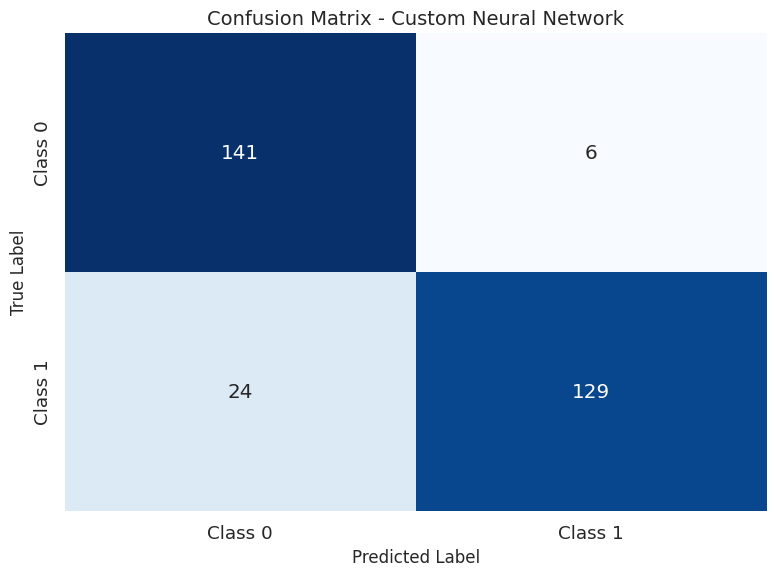

Custom Neural Network Performance:
Accuracy: 0.9000
Precision: 0.9556
Recall: 0.8431
F1 Score: 0.8958


In [12]:
# Evaluate the neural network models we built
def evaluate_models():
    # Get predictions from our custom neural network
    custom_nn_predictions = nn.predict(X_test_scaled)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, custom_nn_predictions)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Class 0', 'Class 1'],
               yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix - Custom Neural Network', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Calculate and print metrics
    accuracy = accuracy_score(y_test, custom_nn_predictions)
    precision = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0
    recall = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print("Custom Neural Network Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Evaluate TensorFlow model if available
    if TF_AVAILABLE:
        # Get predictions from TensorFlow model
        tf_predictions = (model.predict(X_test_scaled) > 0.5).astype(int)
        
        # Compute confusion matrix
        cm_tf = confusion_matrix(y_test, tf_predictions)
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues', cbar=False,
                   xticklabels=['Class 0', 'Class 1'],
                   yticklabels=['Class 0', 'Class 1'])
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.title('Confusion Matrix - TensorFlow/Keras Model', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Calculate and print metrics
        tf_accuracy = accuracy_score(y_test, tf_predictions)
        tf_precision = cm_tf[1, 1] / (cm_tf[1, 1] + cm_tf[0, 1]) if (cm_tf[1, 1] + cm_tf[0, 1]) > 0 else 0
        tf_recall = cm_tf[1, 1] / (cm_tf[1, 1] + cm_tf[1, 0]) if (cm_tf[1, 1] + cm_tf[1, 0]) > 0 else 0
        tf_f1 = 2 * tf_precision * tf_recall / (tf_precision + tf_recall) if (tf_precision + tf_recall) > 0 else 0
        
        print("\nTensorFlow/Keras Model Performance:")
        print(f"Accuracy: {tf_accuracy:.4f}")
        print(f"Precision: {tf_precision:.4f}")
        print(f"Recall: {tf_recall:.4f}")
        print(f"F1 Score: {tf_f1:.4f}")
        
        # Compare model performances
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        custom_scores = [accuracy, precision, recall, f1]
        tf_scores = [tf_accuracy, tf_precision, tf_recall, tf_f1]
        
        plt.figure(figsize=(10, 6))
        x = range(len(metrics))
        width = 0.35
        
        plt.bar(x, custom_scores, width, label='Custom Neural Network', color='blue', alpha=0.7)
        plt.bar([i + width for i in x], tf_scores, width, label='TensorFlow/Keras', color='orange', alpha=0.7)
        
        plt.ylabel('Score', fontsize=12)
        plt.title('Model Performance Comparison', fontsize=14)
        plt.xticks([i + width/2 for i in x], metrics)
        plt.ylim(0, 1.0)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Call the function to evaluate our models
evaluate_models()

## 9. Common Challenges in Neural Networks

Neural networks face several challenges during training and deployment:

### 1. Overfitting
- Network memorizes training data but performs poorly on new data
- Solutions: Regularization (L1/L2), Dropout, Early stopping, Data augmentation

### 2. Vanishing/Exploding Gradients
- Gradients become too small or large during backpropagation
- Solutions: Proper initialization, Batch normalization, Gradient clipping, ReLU activation

### 3. Hyperparameter Tuning
- Finding optimal values for learning rate, batch size, network architecture
- Solutions: Grid/Random search, Bayesian optimization

### 4. Training Time
- Deep networks can take days/weeks to train
- Solutions: Transfer learning, GPUs/TPUs, Distributed training

### 5. Model Interpretability
- Neural networks are "black boxes" with limited explainability
- Solutions: Visualization techniques, Attention mechanisms, SHAP values

Let's demonstrate the overfitting problem and some solutions:

In [13]:
# Demonstrate overfitting and regularization

# Generate a small dataset to encourage overfitting
X_small, y_small = make_classification(n_samples=100, n_features=20, 
                                     n_informative=2, n_redundant=18, 
                                     random_state=42)
y_small = y_small.reshape(-1, 1)

# Split the data
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42)

# Standardize
scaler_small = StandardScaler()
X_train_small_scaled = scaler_small.fit_transform(X_train_small)
X_test_small_scaled = scaler_small.transform(X_test_small)

if TF_AVAILABLE:
    # Create an overfitting-prone model (too many parameters for small dataset)
    overfit_model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(20,)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Create a regularized model
    regularized_model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(20,),
                          kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(32, activation='relu', 
                          kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dropout(0.3),  # Dropout layer
        keras.layers.Dense(16, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dropout(0.3),  # Dropout layer
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Compile both models
    overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    regularized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train both models
    history_overfit = overfit_model.fit(
        X_train_small_scaled, y_train_small,
        epochs=100,
        validation_split=0.2,
        verbose=0
    )
    
    history_regularized = regularized_model.fit(
        X_train_small_scaled, y_train_small,
        epochs=100,
        validation_split=0.2,
        verbose=0
    )
    
    # Plot training histories to demonstrate overfitting
    plt.figure(figsize=(12, 5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history_overfit.history['loss'], 'b-', label='Overfit Train Loss')
    plt.plot(history_overfit.history['val_loss'], 'b--', label='Overfit Val Loss')
    plt.plot(history_regularized.history['loss'], 'r-', label='Regularized Train Loss')
    plt.plot(history_regularized.history['val_loss'], 'r--', label='Regularized Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history_overfit.history['accuracy'], 'b-', label='Overfit Train Acc')
    plt.plot(history_overfit.history['val_accuracy'], 'b--', label='Overfit Val Acc')
    plt.plot(history_regularized.history['accuracy'], 'r-', label='Regularized Train Acc')
    plt.plot(history_regularized.history['val_accuracy'], 'r--', label='Regularized Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Evaluate on the test set
    overfit_loss, overfit_acc = overfit_model.evaluate(X_test_small_scaled, y_test_small, verbose=0)
    regularized_loss, regularized_acc = regularized_model.evaluate(X_test_small_scaled, y_test_small, verbose=0)
    
    print("\nOverfitting and Regularization Comparison:")
    print(f"Overfit Model - Test Loss: {overfit_loss:.4f}, Test Accuracy: {overfit_acc:.4f}")
    print(f"Regularized Model - Test Loss: {regularized_loss:.4f}, Test Accuracy: {regularized_acc:.4f}")
    
    # Show the gap between training and validation performance as a metric of overfitting
    overfit_train_acc = history_overfit.history['accuracy'][-1]
    overfit_val_acc = history_overfit.history['val_accuracy'][-1]
    regularized_train_acc = history_regularized.history['accuracy'][-1]
    regularized_val_acc = history_regularized.history['val_accuracy'][-1]
    
    print("\nOverfitting Gap (Training Accuracy - Validation Accuracy):")
    print(f"Overfit Model: {overfit_train_acc - overfit_val_acc:.4f}")
    print(f"Regularized Model: {regularized_train_acc - regularized_val_acc:.4f}")
    
    # Create a table to summarize regularization techniques
    regularization_techniques = {
        'L1 Regularization': 'Adds the absolute value of weights to the loss function, encourages sparse models',
        'L2 Regularization': 'Adds the squared value of weights to the loss function, discourages large weights',
        'Dropout': 'Randomly sets a fraction of input units to 0 during training, preventing co-adaptation',
        'Early Stopping': 'Stops training when validation performance starts degrading',
        'Data Augmentation': 'Creates variations of training examples to increase dataset size and diversity',
        'Batch Normalization': 'Normalizes activations in intermediate layers, speeds up training and acts as a regularizer'
    }
    
    print("\nCommon Regularization Techniques for Neural Networks:")
    for technique, description in regularization_techniques.items():
        print(f"- {technique}: {description}")
else:
    print("TensorFlow is not available. Skipping overfitting demonstration.")

TensorFlow is not available. Skipping overfitting demonstration.


## 10. Neural Network Architectures

Neural networks come in various architectures, each designed for specific types of problems and data. Here are the major architectures:

### Feedforward Neural Networks (FNN)
- **Structure**: Information flows in one direction from input to output
- **Key features**: Fully connected layers with no cycles or loops
- **Use cases**: Classification, regression, pattern recognition
- **Strengths**: Simple to implement and understand
- **Examples**: Multi-layer perceptrons (MLPs)

### Convolutional Neural Networks (CNN)
- **Structure**: Contains convolutional layers that apply filters to detect patterns
- **Key features**: Weight sharing, local connectivity, pooling layers
- **Use cases**: Image processing, computer vision, pattern detection
- **Strengths**: Translation invariance, feature extraction from spatial data
- **Examples**: ResNet, VGG, Inception, EfficientNet

### Recurrent Neural Networks (RNN)
- **Structure**: Contains feedback connections, allowing information persistence
- **Key features**: Hidden state that acts as memory
- **Use cases**: Sequential data, time series, language modeling
- **Strengths**: Can process variable-length sequences
- **Examples**: Simple RNN, GRU (Gated Recurrent Unit)

### Long Short-Term Memory Networks (LSTM)
- **Structure**: Special RNN with gating mechanisms
- **Key features**: Memory cells with input, forget, and output gates
- **Use cases**: Speech recognition, machine translation, text generation
- **Strengths**: Addresses vanishing gradient problem, captures long-term dependencies
- **Examples**: LSTM, BiLSTM (Bidirectional LSTM)

### Transformer Networks
- **Structure**: Based on self-attention mechanisms instead of recurrence
- **Key features**: Multi-head attention, positional encoding
- **Use cases**: Natural language processing, machine translation
- **Strengths**: Parallel processing, captures long-range dependencies
- **Examples**: BERT, GPT, T5, ViT (Vision Transformer)

### Autoencoder Networks
- **Structure**: Encoder compresses data, decoder reconstructs it
- **Key features**: Bottleneck architecture with dimensionality reduction
- **Use cases**: Dimensionality reduction, anomaly detection, generative tasks
- **Strengths**: Unsupervised feature learning
- **Examples**: Variational Autoencoders (VAE), Denoising Autoencoders

### Generative Adversarial Networks (GAN)
- **Structure**: Two networks (generator and discriminator) compete
- **Key features**: Adversarial training process
- **Use cases**: Image generation, style transfer, data augmentation
- **Strengths**: Can generate highly realistic synthetic data
- **Examples**: DCGAN, StyleGAN, CycleGAN

### Graph Neural Networks (GNN)
- **Structure**: Process data represented as graphs
- **Key features**: Message passing between nodes
- **Use cases**: Social network analysis, molecular chemistry, recommender systems
- **Strengths**: Can handle irregularly structured data
- **Examples**: GCN (Graph Convolutional Network), GAT (Graph Attention Network)

## 10. Summary and Conclusion

In this notebook, we've explored the fundamentals of neural networks, including:

1. **Neural Network Components**: We learned about neurons, weights, biases, activation functions, and layers.

2. **Activation Functions**: We implemented and visualized common activation functions like sigmoid, tanh, ReLU, and leaky ReLU.

3. **Neural Network Implementation**: We built a neural network from scratch using NumPy and also implemented one using TensorFlow/Keras.

4. **Training and Evaluation**: We trained both models on a classification dataset and evaluated their performance using various metrics.

5. **Neural Network Architectures**: We explored different neural network architectures, including feedforward, CNN, RNN, and LSTM networks.

6. **Challenges and Solutions**: We discussed common challenges in neural networks, such as overfitting, and demonstrated solutions like regularization.

Neural networks form the foundation of modern deep learning and have enabled numerous advances in artificial intelligence. They're particularly powerful for tasks involving pattern recognition, including image classification, natural language processing, and time series prediction.

### Next Steps

To continue your neural network journey, consider exploring:

1. **Deep Learning Frameworks**: Dive deeper into TensorFlow, PyTorch, or JAX.
2. **Advanced Architectures**: Study more complex architectures like transformers, GANs, or reinforcement learning models.
3. **Real-World Applications**: Apply neural networks to real-world datasets and problems.
4. **Model Optimization**: Learn techniques for optimizing neural networks for speed and efficiency.
5. **Specialized Domains**: Explore neural networks in domains like computer vision, natural language processing, or audio processing.